In [1]:
# Generic packages
import numpy as np 
import matplotlib.pyplot as plt
from os import listdir

# Style 
plt.style.use('seaborn-pastel')

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA, KernelPCA, NMF
from sklearn.model_selection import train_test_split
from sklearn.neighbors import NeighborhoodComponentsAnalysis
from sklearn.manifold import Isomap, TSNE, SpectralEmbedding, LocallyLinearEmbedding, MDS
from sklearn.mixture import GaussianMixture, BayesianGaussianMixture
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import SelectFromModel

### Functions

In [2]:
def build_dataset(path):
    """
    build_dataset(path)

        Import dataset from path, normalize data and separate in train and test datasets.

        -path (str) : Path to the dataset files. 
    """
    TES = np.concatenate([np.fromfile(f"{path}{fileName}",dtype=np.uint16).reshape(-1,496) for fileName in listdir(path)])
    shape = np.shape(TES)

    #X = (X - np.mean(X)) / (np.std(X))
    X = (TES - np.min(TES)) / (np.max(TES) - np.min(TES))

    X_train, X_test = train_test_split(X, test_size=0.01, random_state=0)

    print(f"Dataset contains :",
        f"\nSamples : {shape[0]}",
        f"\nLenght of samples : {shape[1]}",
        f"\nNumber of train samples : {len(X_train)}",
        f"\nNumber of test samples {len(X_test)}")
    
    return X_train , X_test

In [3]:
def method(X,function,**param):
    """
    # method()

    Verifies if a function has been saved in the `Preprocess` folder to avoid unnecessary computation. 

    -X (any) : Inputs of the function that needs to be computed.
    -function (function) : Function that is executed.
    -param (**kwargs) : Multiple keyword arguments to define the parameters of `function`.
    
    """
    # File name
    file_name = f"{str(function.__name__)}_{str(param.items())}"
    print("File name : ", file_name)

    # Check for existing file
    try:
        result = np.load(f"Preprocess\{file_name}.npy",allow_pickle=True)

    # Compute operation if file does not exist
    except:
        method = function(**param)
        result = method.fit_transform(X)
        np.save(f"Preprocess\{file_name}",arr=result)
    
    # Plot results
    #plt.scatter(result[:, 0], result[:, 1],alpha=0.1,color=[0.5,0.5,0.5])
    #plt.xlabel('First principal component')
    #plt.ylabel('Second principal component')

    plt.hist2d(result[:, 0], result[:, 1],bins=300)

    return result

### Plot TES

Dataset contains : 
Samples : 52224 
Lenght of samples : 496 
Number of train samples : 51701 
Number of test samples 523


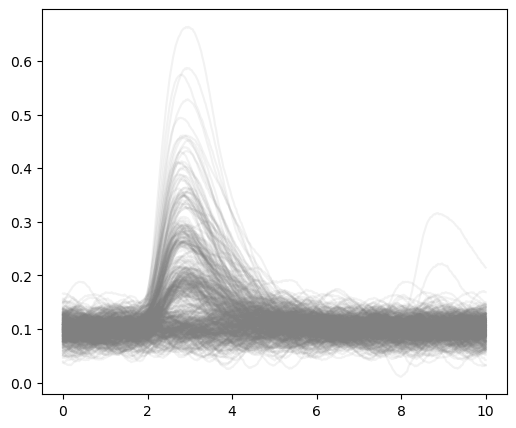

In [4]:
X, X_test = build_dataset("Datasets/Guillaume Thekkadath/")
signalSize = len(X_test[0])
time = np.linspace(0,10,signalSize)

plt.figure(figsize=(6,5))
plot = [plt.plot(time, X[i], color=[0.5,0.5,0.5],alpha=0.1) for i in range(signalSize)]

### Principal Component Analysis (PCA)

File name :  PCA_dict_items([('n_components', 2)])


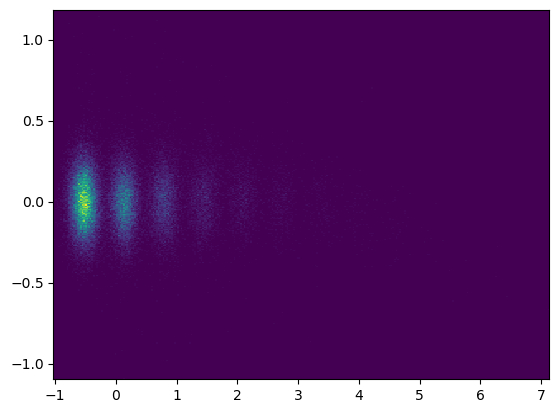

In [5]:
X_pca = method(X,PCA,n_components=2)

### Kernel 

#### Polynomial

Poly : $K(x, y)=\left(x^{\top} y+c\right)^d$

- x and y = input column vectors and d = kernel degree

File name :  KernelPCA_dict_items([('n_components', 2), ('kernel', 'poly')])


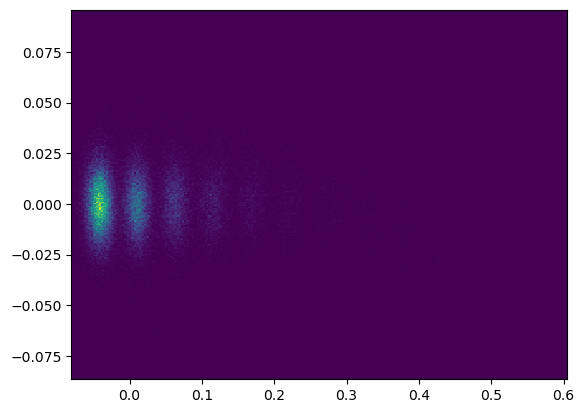

In [6]:
X_kernel_poly = method(X,KernelPCA,n_components=2,kernel="poly")

#### Radial basis function (RBF)

File name :  KernelPCA_dict_items([('n_components', 2), ('kernel', 'rbf'), ('gamma', 0.02)])


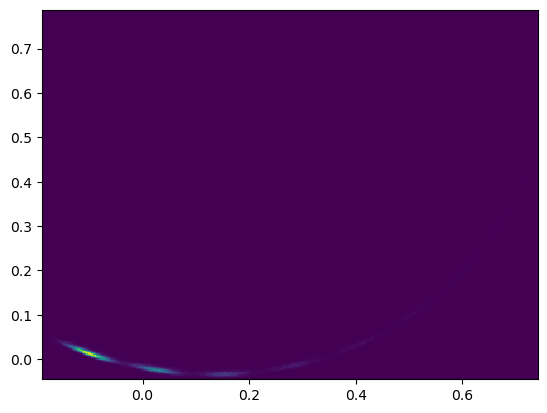

In [7]:
X_kernel_rbf = method(X,KernelPCA,n_components=2,kernel="rbf",gamma=0.02)

#### Sigmoid

File name :  KernelPCA_dict_items([('n_components', 2), ('kernel', 'sigmoid'), ('gamma', 0.02)])


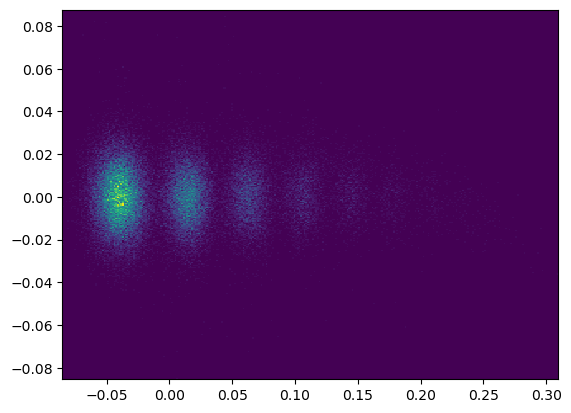

In [8]:
X_kernel_sigmoid = method(X,KernelPCA,n_components=2,kernel="sigmoid",gamma=0.02)

#### Cosine

File name :  KernelPCA_dict_items([('n_components', 2), ('kernel', 'cosine'), ('gamma', 0.02)])


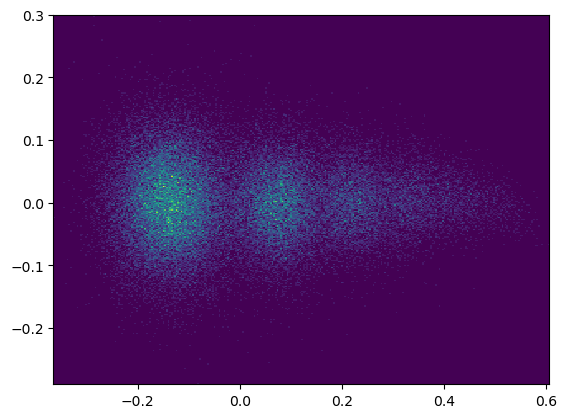

In [9]:
X_kernel_cosine = method(X,KernelPCA,n_components=2,kernel="cosine",gamma=0.02)

### t-distributed Stochastic Neighbor Embedding (t-SNE)



File name :  TSNE_dict_items([('random_state', 42), ('n_components', 2), ('init', 'random'), ('learning_rate', 200)])


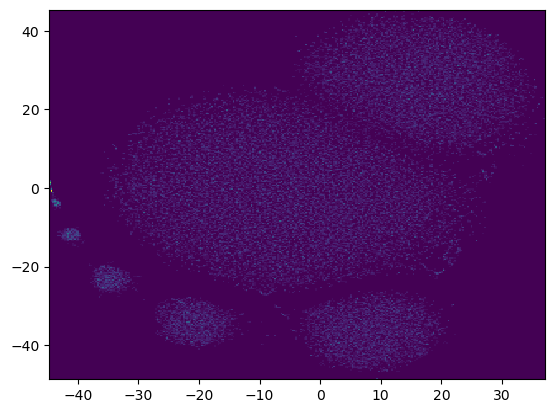

In [10]:
X_tsne = method(X,TSNE,random_state=42,n_components=2,init="random",learning_rate=200)

### Non-Negative Matrix Factorization (NMF)

File name :  NMF_dict_items([('n_components', 4), ('alpha_W', 0.1), ('random_state', 42)])


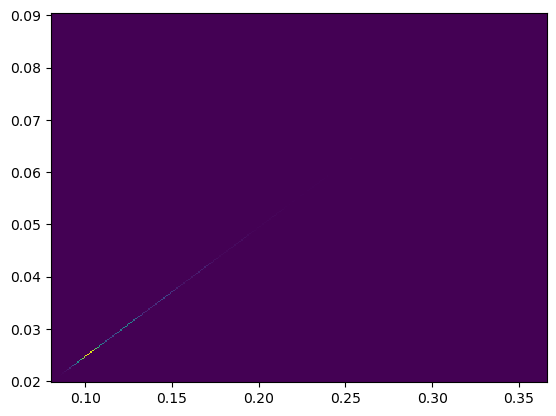

In [11]:
X_NMF = method(X,NMF,n_components=4,alpha_W=0.1,random_state=42)

### Isomap

In [12]:
#X_Isomap = method(X,Isomap,n_components=2)

### Multidimensional scaling

In [13]:
#X_MDS = method(X,MDS,n_components=2,max_iter=10)

### Locally Linear Embedding (LLE)

In [14]:
#X_LLE = method(X,LocallyLinearEmbedding,n_components=2)